<table>
  <tr>
    <td><div align="left"><font size="30">Machine Vision Toolbox for Python</font></div></td>
    <td><img src="support/figs/VisionToolboxLogo_NoBackgndx.png" width="200"></td>
  </tr>
</table>

<p></p>
<div align="center" style="font-size: 1.5em;">🧑‍💻 OpenCV for humans</div>
<p></p>


(c) Peter Corke 2026

In [1]:
import importlib
import setup_tutorial
importlib.reload(setup_tutorial)
await setup_tutorial.setup_tutorial(required_toolboxes=['machinevisiontoolbox'], required_packages=['opencv','matplotlib', 'numpy', 'scipy'])

print("\nmachinevision toolbox version:", importlib.import_module("machinevisiontoolbox").__version__)


Setting up tutorial environment — wait for the ✅
setup_tutorial: environment=local Python
setup_tutorial: required_toolboxes=['machinevisiontoolbox']
setup_tutorial: required_packages=['opencv', 'matplotlib', 'numpy', 'scipy']
setup_tutorial: toolbox 'machinevisiontoolbox' source=already installed in environment
✅ Setup complete — toolboxes: machinevisiontoolbox; packages: opencv-python, matplotlib, numpy, scipy

machinevision toolbox version: 1.1.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(linewidth=100, threshold=100, formatter={'float': lambda x: f"{x:8.3g}" if abs(x) > 1e-10 else f"{0:8.3g}"})

# The Image class

Unlike OpenCV, this Toolbox considers images as objects, not generic NumPy arrays. This has huge advantages as I hope you will see.

To read a color image into a Python object is simply

In [3]:
from machinevisiontoolbox import Image

image = Image.Read("flowers4.png")

and the result is an image container, a Numpy array holding the pixels encapsulated by an object that includes metadata and a boatload of methods and properties.

We can see a lot of pertinant information about the image by

In [4]:
print(image)

Image: 640 x 426 (uint8), R:G:B [.../images/flowers4.png]
  R: span=[0, 255]; mean=97.9412, 𝜎=56.7939; median=91
  G: span=[0, 255]; mean=103.689, 𝜎=54.6656; median=101
  B: span=[0, 255]; mean=43.2257, 𝜎=43.1836; median=35


which says that the image contains 3 "color planes" named R, G and B, and each plane is 640x426.

And, we can display it as an image

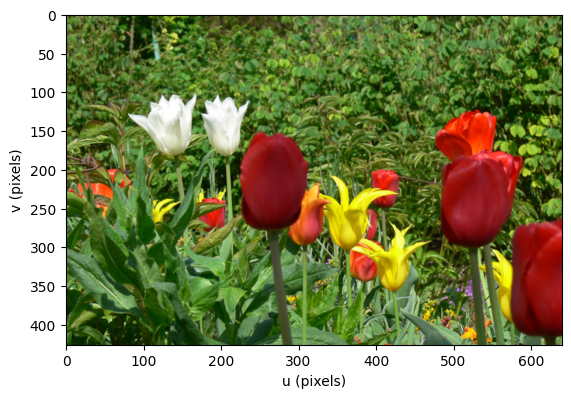

In [5]:
image.disp();

🐛 **In the JupyterLite environment the pixel value browsing function doesn't work**.

In [6]:
image.size

(640, 426)

that is, it is 640x426.

We can pull out the NumPy array that holds the pixels

In [7]:
image.array

array([[[113, 126,  55],
        [125, 140,  70],
        [136, 138,  80],
        ...,
        [105, 160,  84],
        [ 96, 156,  76],
        [ 90, 156,  71]],

       [[111, 126,  55],
        [123, 132,  69],
        [131, 127,  79],
        ...,
        [101, 144,  71],
        [ 96, 146,  68],
        [ 96, 151,  72]],

       [[121, 134,  70],
        [127, 131,  78],
        [123, 117,  77],
        ...,
        [ 60,  96,  26],
        [ 74, 116,  41],
        [ 96, 143,  66]],

       ...,

       [[ 33,  66,  13],
        [ 41,  91,  11],
        [ 33,  90,   2],
        ...,
        [141, 175, 100],
        [118, 150,  73],
        [104, 145,  71]],

       [[  4,  45,   0],
        [ 19,  62,   3],
        [ 35,  86,   4],
        ...,
        [152, 182, 113],
        [135, 169,  88],
        [118, 157,  76]],

       [[ 23,  67,   2],
        [  8,  50,   0],
        [ 29,  72,   6],
        ...,
        [165, 186, 119],
        [139, 164,  78],
        [113, 144,  65]]

which is simply a big 3-dimensional array of 8-bit unsigned integers.

To make this clearer, we can access the value of the pixel at image coordinate (516,351), remember that's (horizontal, vertical) coordinate

In [8]:
image[516,351]

array([193, 119, 232], dtype=uint8)

which is a 3-element 1-dimensional array with `uint8` values.  This is the intensity of red, green and blue respectively.


## Color planes

We can also think of the color image as a stack of three greyscale images that each represent the amoung of redness, greenness and blueness (effectively what the scene looks like through a red, green or blue filter).

Note that we can have images with 2, 3, 4 or more planes.  Hyperspectral cameras can "see" uptp 20 colors (often called bands, short for spectral bands).  The number of planes in the image is given by

In [9]:
image.nplanes

3

Some images might have 3 planes but they represent hue, saturation and intensity, rather than red, green and blue. The names of the planes, and which "layer" in the 3D-array they are in is given by 

In [10]:
image.colororder

{'R': 0, 'G': 1, 'B': 2}


Let's let more closely at one of these color planes -- the red plane.

In [11]:
red = image.red()
red

Image(size=(640, 426), dtype=uint8)

and we see that is a greyscale image.  The intensity of each pixel is the amount of red at the corresponding pixel in the original color image.

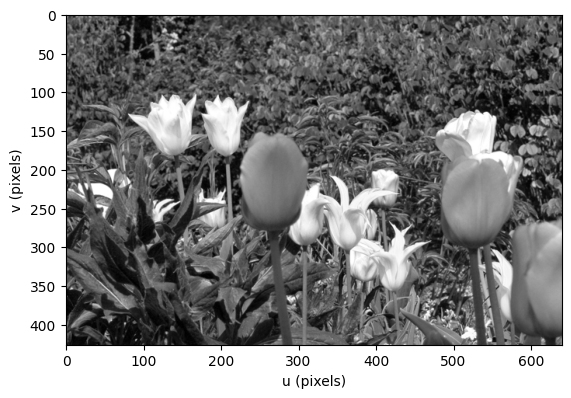

In [12]:
red.disp()

We could also have written `image.plane(0)`, `image.plane("R")`, or `image[0]`.

## Greyscale and color conversion

We can convert a color image to a greyscale image

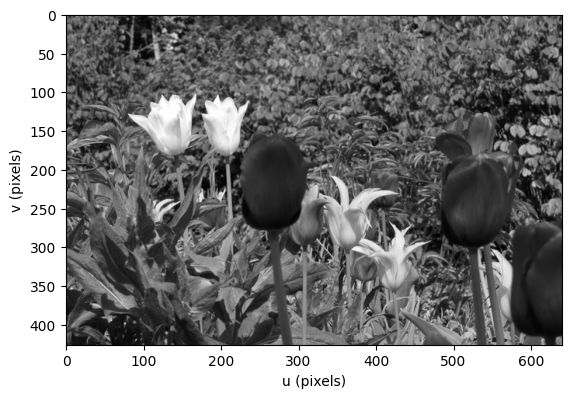

In [13]:
image.mono().disp()

where the greyscale value is a weighted average of the red, greend and blue values.  The hightest weighting is for green and the lowest weighting is for blue, to match the response of the human eye.

We could also colorize the red plane image from above. Here we say that the red value is equal to the corresponding greyscale value, while green and blue are set to zero.  The result is a color image, but the only color is red.

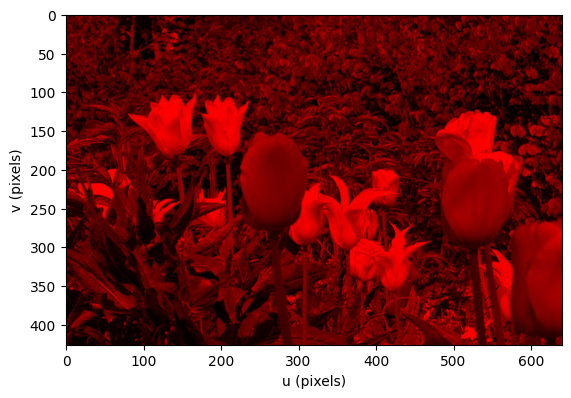

In [14]:
red.colorize([1,0,0]).disp()

## Histograms

Often we are interested to know the distribution of the pixel values in each plane

In [15]:
image.stats

{'R': {'min': 0.0,
  'max': 255.0,
  'mean': 97.94123752934273,
  'sdev': 56.793911574179766,
  'median': 91.0,
  'nnan': 0,
  'ninf': 0},
 'G': {'min': 0.0,
  'max': 255.0,
  'mean': 103.68855633802816,
  'sdev': 54.665575876816746,
  'median': 101.0,
  'nnan': 0,
  'ninf': 0},
 'B': {'min': 0.0,
  'max': 255.0,
  'mean': 43.225700557511736,
  'sdev': 43.18362062080349,
  'median': 35.0,
  'nnan': 0,
  'ninf': 0}}

which shows that the pixels span the full range from 0 to 255.  A histogram provides more nuanced information

In [16]:
hist = image.hist()
hist

Histogram(nbins=256, nplanes=3, xrange=(0, 255), yrange=(20, 34229))

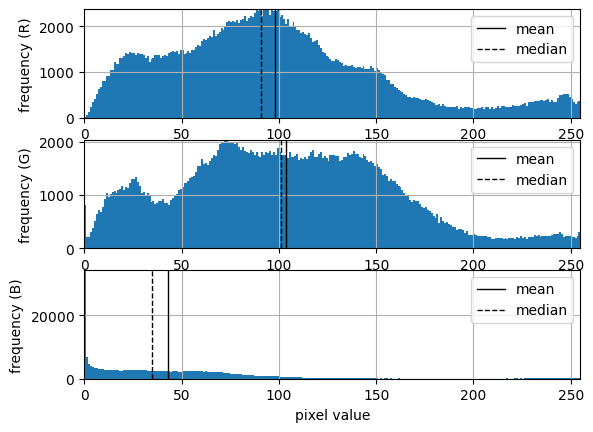

In [17]:
hist.plot()

# Standard image processing operations

## Monadic image operations


We will work with a greyscale version of the Mona Lisa image

In [18]:
mona = Image.Read("monalisa.png", grey=True)


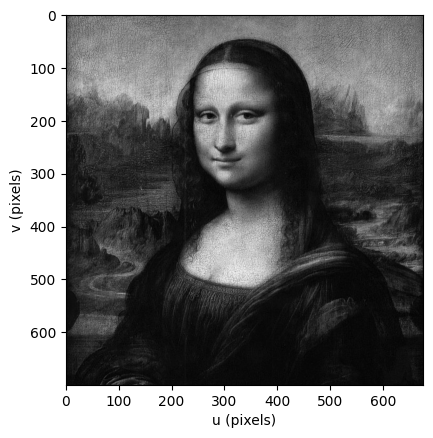

In [19]:
from machinevisiontoolbox.base import idisp

idisp(mona.array)

First, we display some simple statistics on the minimum and maximum pixel values

In [20]:
mona.stats

{'min': 1.0,
 'max': 233.0,
 'mean': 61.27127664064149,
 'sdev': 52.38048612295789,
 'median': 40.0,
 'nnan': 0,
 'ninf': 0}

and we see that the average pixel value is well below the mid value of 128.

To get a more nuanced idea of pixel value distribution we will compute a histogram

In [21]:
histo = mona.hist()
histo

Histogram(nbins=256, nplanes=1, xrange=(0, 255), yrange=(0, 18113))

and plot it

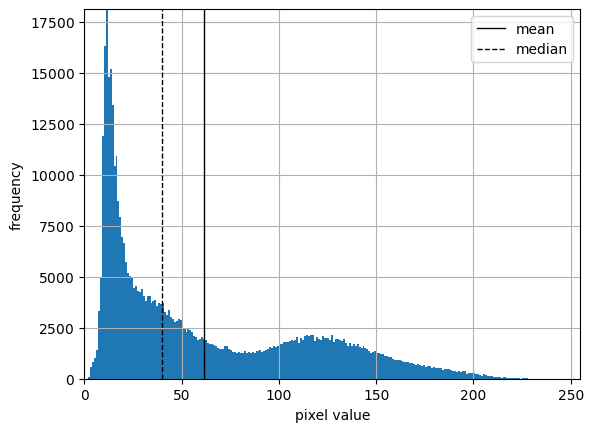

In [22]:
histo.plot()

We can attempt to brighten the image by multiplying all the pixel values by 1.5.  We need to be careful that the values don't exceed the range of the `uint8` type.

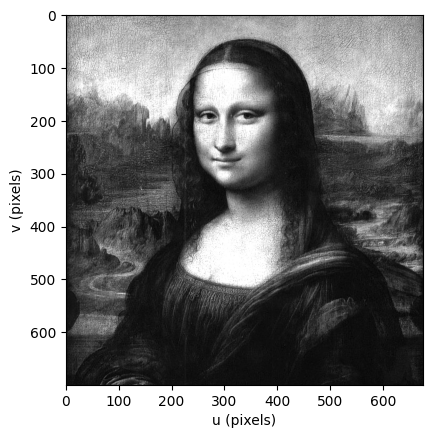

In [23]:
mona.apply(lambda x: np.uint8(np.clip(x*1.5, 0, 255))).disp(vrange=[0,255])

A simple art effect is posterization where we quantise the pixel values

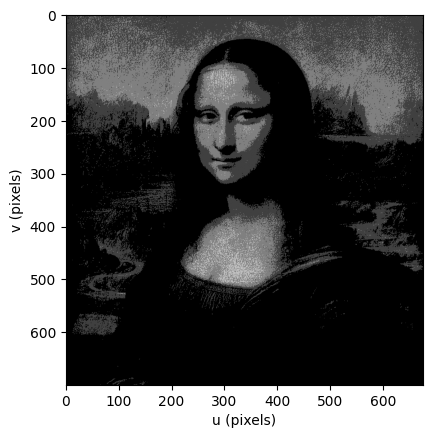

In [24]:
(mona // 64 * 64).disp(vrange=[0,255])

And we can apply a threshold, testing whether or not each pixel value exceeds 100. The resulting image has pixel values which are either True or False

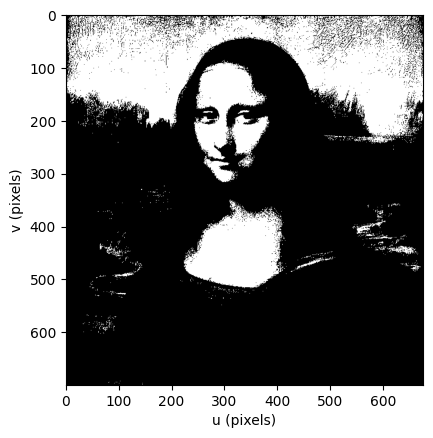

In [25]:
(mona > 100).disp()

## Green screening

This is a very common technique in video production, and these days even with video conferencing tools.  We load our foreground image, the one we'd like to superimpose on the background.  In a video this would be the presenter.

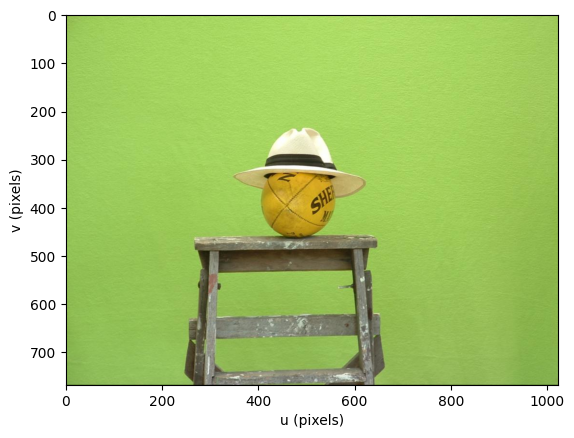

In [26]:
foreground = Image.Read('greenscreen.png', dtype='float')
foreground.disp()

Now we need to determine which pixels are green, the background to be discarded.  We gamma decode the image and compute the chromacity of every pixel $r=R/(R+G+B), g=G/(R+G+B)$.  The result is an image with two planes

In [27]:
cc = foreground.gamma_decode('sRGB').chromaticity()
print(cc)

Image: 1024 x 768 (float32), r:g
  r: span=[0.257347, 0.853837]; mean=0.342649, 𝜎=0.0511269; median=0.328765
  g: span=[0.146163, 0.742653]; mean=0.545529, 𝜎=0.0680924; median=0.570763


We will apply a threshold to $g$ but we need to understand the distribution before we can choose the threshold value.  For that we'll compute and display a histogram.

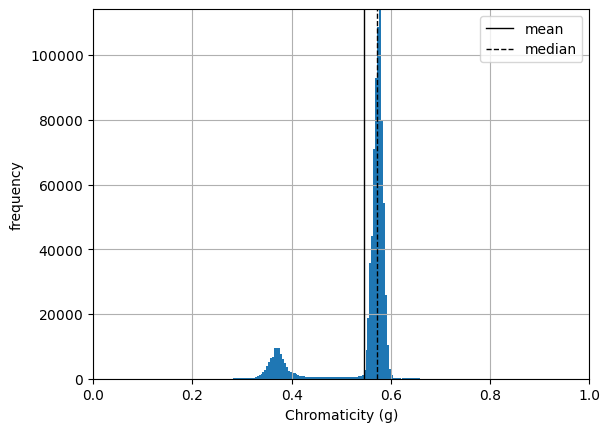

In [28]:
h = cc.plane('g').hist()
h.plot(block=None)
plt.xlabel('Chromaticity (g)');
plt.grid(True)


The big strong green peak on the right is the green background, the other peak is the foreground object.  A threshold of 0.45 nicely separates the two pixel populations.

Image: 1024 x 768 (bool), 1 anonymous plane
  span=[0, 1]; mean=0.126736, 𝜎=0.332677; median=0


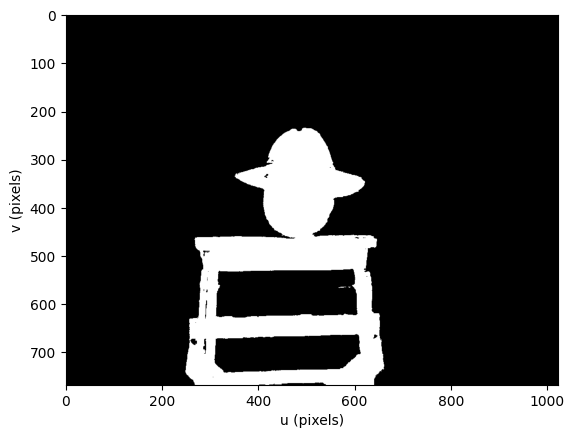

In [29]:
mask = cc.plane('g') < 0.45
mask.disp()
print(mask)


The result is a logical image where True pixels indicate foreground pixels.

We want to apply this mask to a color image so we replicate this value across the RGB color channels

In [30]:
mask3 = mask.colorize()
print(mask3)

Image: 1024 x 768 (bool), R:G:B
  R: span=[0, 1]; mean=0.126736, 𝜎=0.332677; median=0
  G: span=[0, 1]; mean=0.126736, 𝜎=0.332677; median=0
  B: span=[0, 1]; mean=0.126736, 𝜎=0.332677; median=0


which we see is a color image where the R, G, and B planes are the image above.

Now we can apply the mask to the foreground image and display it.

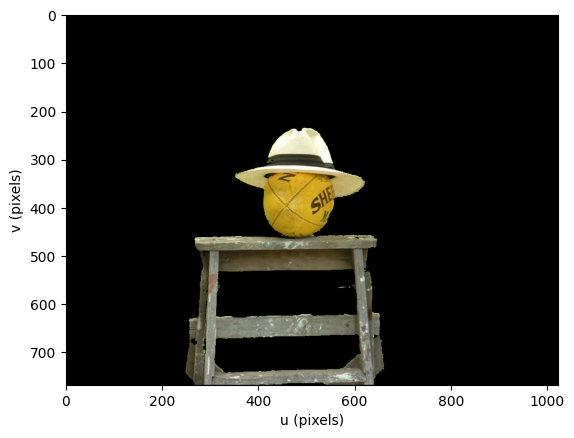

In [31]:
(foreground * mask3).disp()

Happily, all the green pixels have now gone.

Next we load the background image, and clip and scale it to be the same size as the foreground image.

In [32]:
background = Image.Read("road.png", dtype="float").samesize(foreground)

and then apply the inverse mask to it.  Note that in Python `True`=1 and `False`=0.

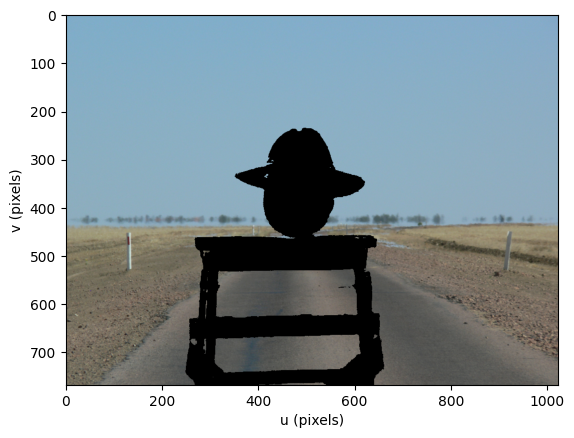

In [33]:
(background * (1 - mask3)).disp();

Now, all that's left to do is to add the masked foreground image to the inverse masked background image

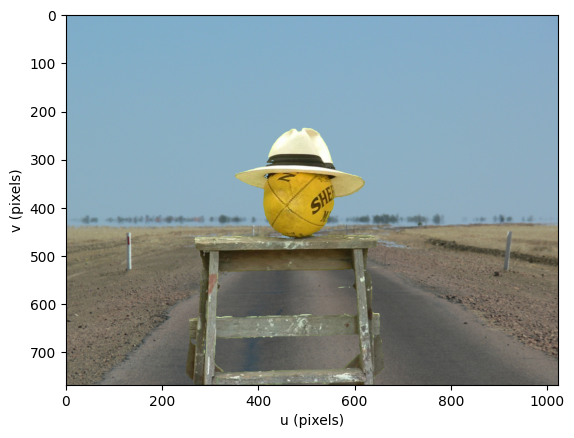

In [34]:
(foreground * mask3  + background * (1 - mask3)).disp();

# Spatial operations

Now let's load a real greyscale image from a PNG file.  This particular image file is distributed with the Toolbox, but you can pass in the path to any image file you might have.  _If the Toolbox can't find the specified image it defaults to looking in the folder of images distributed with the Toolbox._

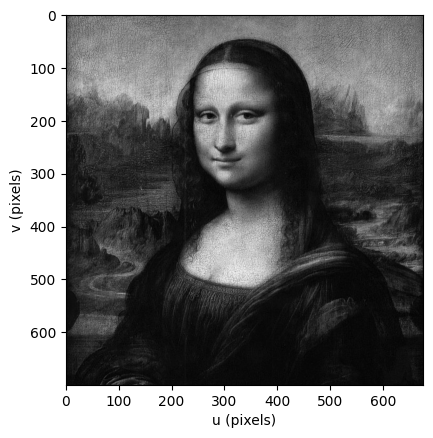

In [35]:
mona = Image.Read("monalisa.png", mono=True)  # convert to monochrome
mona.disp();

For image smoothing it is preferable to use a kernel that is isotropic and symmetric such as a 2D Gaussian

$G(u,v) = \frac{1}{2\pi\sigma^2}e^{-\frac{u^2+v^2}{2\sigma^2}}$

  We will create a 2D Gaussian with $\sigma=10$

In [36]:
from machinevisiontoolbox import Kernel

K = Kernel.Gauss(10)
print(K)

Kernel: 61x61, min=2e-07, max=0.0016, mean=0.00027, SYMMETRIC (Gaussian σ=10)


We can display the kernel as a 3-dimensional mesh.

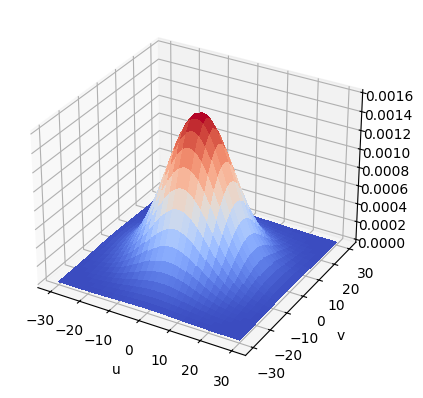

In [37]:
K.disp3d()

Now we can convolve the image with this kernel

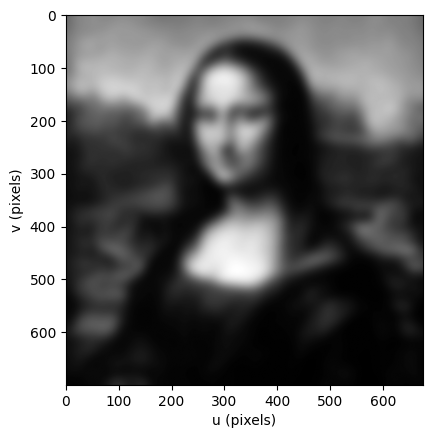

In [38]:
mona.convolve(K).disp();

We can do this more simply using the `smooth` method which accepts $\sigma$ and the half-kernel width.

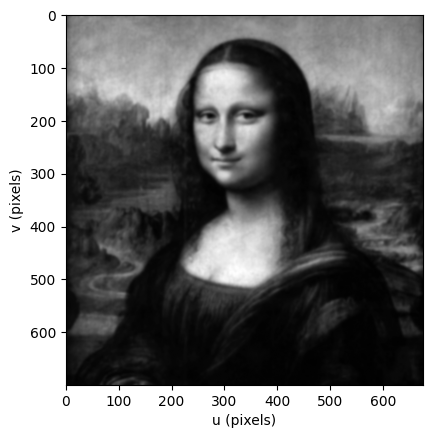

In [39]:
mona.smooth(2, 5).disp();

which shows how method chaining can be used to create simple and readable processing **pipelines** read from left to right.

image[mona] → smooth(2,5) → display

## Finding edges
We can use 2D filtering to find edges as well.  This convolution kernel will find vertical edges.  The intuition is that each row of this kernel subtracts the pixel to the left from the pixel to the right, which will give a positive value if the intensity is increasing left to right.

In [40]:
kernel = Kernel.DoG(2, 5)

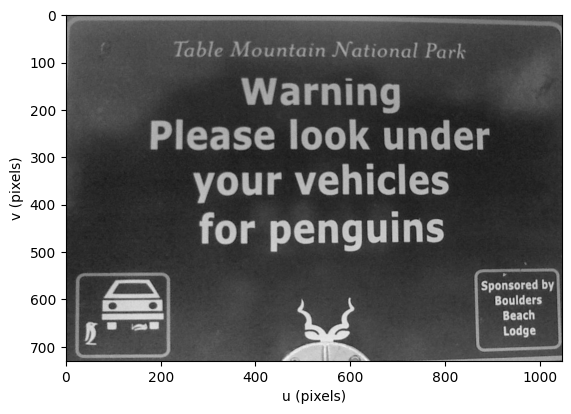

In [41]:
penguins = Image.Read('penguins.png', grey=True, dtype='float')
penguins.disp();

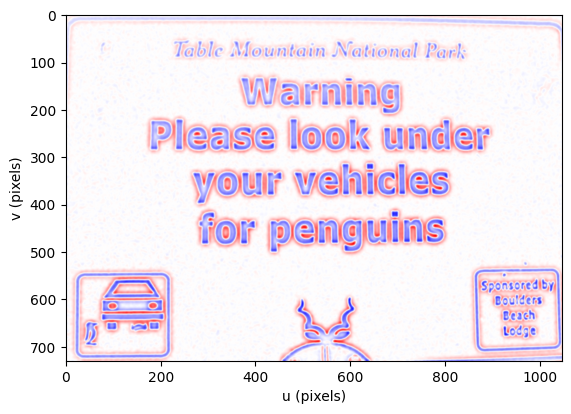

In [42]:
gradient_horizontal = penguins.convolve(kernel)
gradient_horizontal.disp(colormap='signed');                

The image is displayed with a color map that shows negative numbers as red and positive numbers as blue.  Zoom in on the outline of the "P" (use the second button from the right in the bottom toolbar) and you can see that the intensity goes up (blue) on the left side of the "P", from the grey background to the white paint. It goes down (red) on right of the stem, from the white paint to the gray background.

We can find the horizontal edges by finding vertical gradient, using the transpose of the kernel

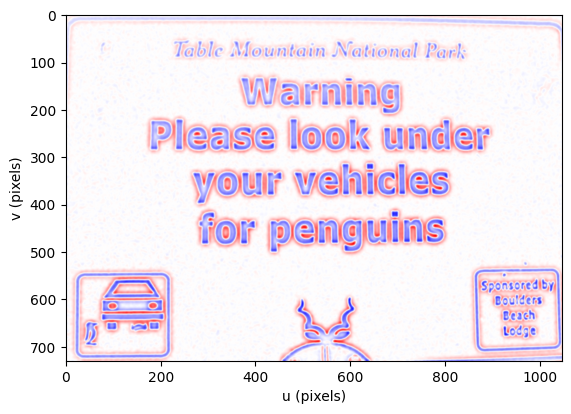

In [43]:
gradient_vertical = penguins.convolve(kernel.T)
gradient_vertical.disp(colormap='signed');    

# Image regions

We start by loading a simple binary image

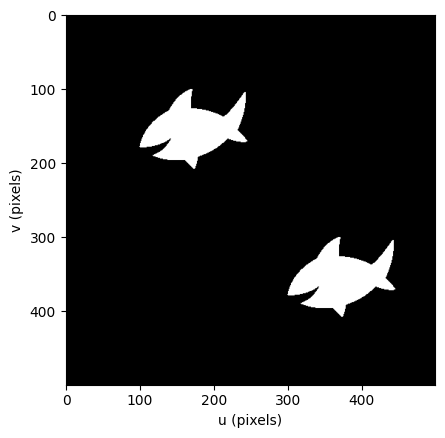

In [44]:
sharks = Image.Read("./shark2.png")
sharks.disp();

When we look at this we see two white objects, vaguely-shark shaped, against a black background.  

Finding the "objects" in the scene, grouping adjacent pixels of the same color. is a very classical computer vision algorithm. Such objects in a binary object are often called *blobs*.

Using this toolbox we simply write

In [45]:
blobs = sharks.blobs();

The result is a feature object that describes the *blobs* present in the scene.
In this case there are


In [46]:
len(blobs)

2

Each blob has a number of properties which are shown in the columns of the table.


In [47]:
print(blobs)

┌────┬────────┬──────────────┬──────────┬───────┬───────┬────────┬────────┬────────┐
│ id │ parent │     centroid │     area │ touch │ perim │ circul │ orient │ aspect │
├────┼────────┼──────────────┼──────────┼───────┼───────┼────────┼────────┼────────┤
│  0 │     -1 │ 371.2, 355.2 │ 7.59e+03 │ False │ 556.6 │  0.343 │ -11.7° │  0.584 │
│  1 │     -1 │ 171.2, 155.2 │ 7.59e+03 │ False │ 556.6 │  0.343 │ -11.7° │  0.584 │
└────┴────────┴──────────────┴──────────┴───────┴───────┴────────┴────────┴────────┘



We can put a box around the blobs and label them with their `id` number.

{'color': 'yellow', 'linewidth': 2}


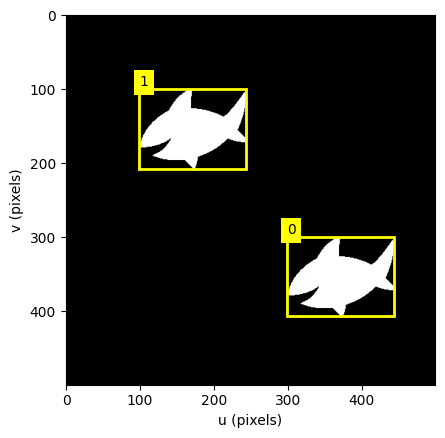

In [48]:
sharks.disp(block=None)
blobs.plot_labelbox(color="yellow", linewidth=2)

This `blobs` object can be indexed or sliced just like a list.  Each element has a number of properties which were listed in the table earlier.  For example, its centroid (centre of mass) is

In [49]:
blobs[0].centroid

(371.2073205542015, 355.18802011286033)

its area in pixels

In [50]:
blobs[0].area

7590.5

and a bounding box

In [51]:
blobs[0].bbox

array([299, 444, 300, 407])

where the first row is the u-axis range, and the second row is the v-axis range.  Alternatively we can consider the columns: the first column is the top-left coordinate and the second column is the bottom-right coordinate.

For each blob we can obtain the length of its perimeter

In [52]:
blobs[0].perimeter_length

556.5706294775009

as well as the perimeter, as a set of points

In [53]:
print(blobs[0].perimeter)

[[367 366 365 ... 370 369 368]
 [300 301 301 ... 300 300 300]]


A simple but useful measure of "shape" is circularity, computed from area and perimeter.  It is 1 for a circle and 0 for a line.

In [54]:
blobs[0].circularity

np.float64(0.34258515276788193)

These properties can also be computed on a list of blob objects, and the result is an array or list. For example

In [55]:
blobs.area

array([7.59e+03, 7.59e+03])

In [56]:
blobs.centroid

[(371.2073205542015, 355.18802011286033),
 (171.20732055420152, 155.18802011286036)]

The blob objects also support some graphical operations.
which depicts and labels each blob.  We also marked the centroids.

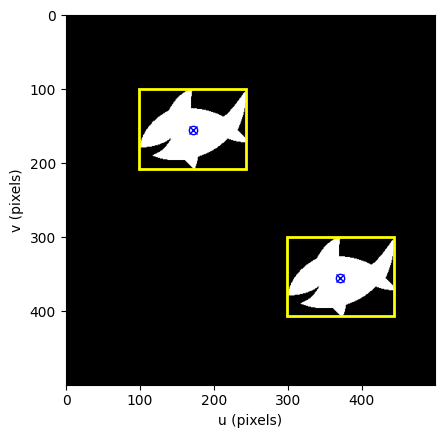

In [57]:
sharks.disp(block=None)
blobs.plot_box(color="yellow", linewidth=2)
blobs.plot_centroid();

## Hierarchical blobs

Now we will load a more complex image that has blobs with holes that contain blobs with holes...

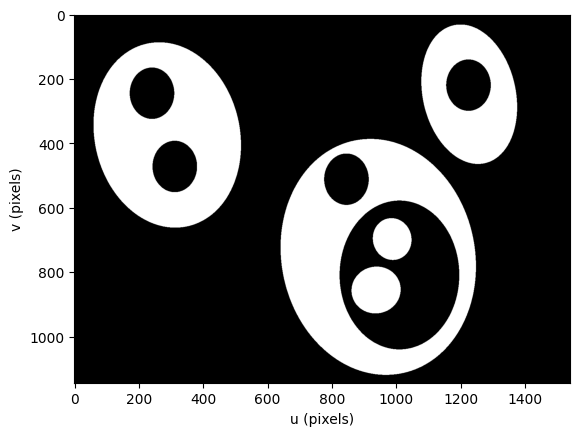

In [58]:
multi = Image.Read("multiblobs.png", grey=True)
multi.disp();

In [59]:
blobs = multi.blobs()
len(blobs)

10

and display the parameters as a table

In [60]:
print(blobs)

┌────┬────────┬───────────────┬──────────┬───────┬────────┬────────┬─────────┬────────┐
│ id │ parent │      centroid │     area │ touch │  perim │ circul │  orient │ aspect │
├────┼────────┼───────────────┼──────────┼───────┼────────┼────────┼─────────┼────────┤
│  0 │     -1 │  907.9, 735.1 │ 1.94e+05 │ False │ 2219.0 │  0.551 │ -103.6° │  0.814 │
│  1 │      0 │ 1025.0, 813.7 │ 1.06e+05 │ False │ 1386.9 │  0.770 │  -90.0° │  0.802 │
│  2 │      1 │  938.1, 855.2 │ 1.72e+04 │ False │  489.7 │  1.005 │  -12.5° │  0.945 │
│  3 │      1 │  988.1, 697.2 │ 1.21e+04 │ False │  411.5 │  0.999 │ -102.8° │  0.919 │
│  4 │      0 │  846.0, 511.7 │ 1.75e+04 │ False │  495.9 │  0.996 │  -90.1° │  0.871 │
│  5 │     -1 │  291.7, 377.8 │  1.7e+05 │ False │ 1711.6 │  0.811 │ -102.9° │  0.775 │
│  6 │      5 │  312.7, 472.1 │ 1.75e+04 │ False │  494.5 │  1.001 │  -90.2° │   0.87 │
│  7 │      5 │  241.9, 245.0 │ 1.75e+04 │ False │  495.9 │  0.996 │  -90.1° │  0.871 │
│  8 │     -1 │ 1228.0, 254.3 │ 

The parent of blob 2 is

In [61]:
blobs[2].parent

1

And the children of blob 2 are

In [62]:
blobs[1].children

[2, 3]

The obvious representation is a tree

In [63]:
from IPython.display import Markdown, display

# Render dynamically via Jupyter's built-in Mermaid engine
display(Markdown(blobs.graph(format="mermaid_fenced")))
print()

```mermaid
flowchart TB
    b0["-1"]
    b1["0"]
    b2["1"]
    b3["2"]
    b4["3"]
    b5["4"]
    b6["5"]
    b7["6"]
    b8["7"]
    b9["8"]
    b10["9"]
    b0 --> b1
    b1 --> b2
    b2 --> b3
    b2 --> b4
    b1 --> b5
    b0 --> b6
    b6 --> b7
    b6 --> b8
    b0 --> b9
    b9 --> b10
```


The final thing we will do is to create a label image, a pixel classification, and display it

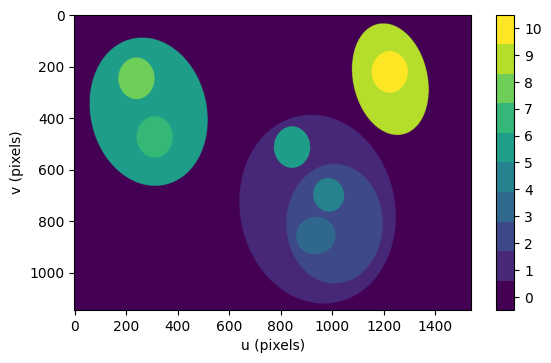

In [64]:
labels = blobs.label_image()
labels.disp(
    colormap="viridis",
    ncolors=10,
    colorbar=dict(shrink=0.8, aspect=20 * 0.8),
    block=True,
);

Where the value of each pixel is the `id` of the blob it belongs to.  By drifting the cursor over the image you can see which pixels belong to say blob #6.  The image uses a colorful colormap to make it easy to see the different label areas.

# Camera modeling

The toolbox provides classes to model various types of cameras:

* `CentralCamera` a "standard" perspective camera like your eye or a digital camera, lines always map to lines
* `FisheyeCamera` a wide-angle camera, where lines don't map to lines
* `CatadoptricCamera` a panoramic camera with a lense and mirror, where lines don't map to lines
* `SphericalCamera` a non-implementable ideal camera with spherical field of view

We'll create a model of a regular camera.

First, define some parameters of our camera

In [65]:
f = 8*1e-3     # focal length in metres
rho = 10*1e-6  # pixel side length in metres
u0 = 500       # principal point, horizontal coordinate
v0 = 500       # principal point, vertical coordinate

In [66]:
from machinevisiontoolbox import CentralCamera

camera = CentralCamera(f=f, rho=rho, pp=(u0, v0), imagesize=1000)
print(camera)

           Name: perspective [CentralCamera]
     pixel size: 9.999999999999999e-06 x 9.999999999999999e-06
     image size: 1000 x 1000
           pose: t = 0, 0, 0; rpy/yxz = 0°, 0°, 0°
   principal pt: [     500      500]
   focal length: [   0.008    0.008]



We can very conveniently project points to the image plane

In [67]:
P = [1,1,5]
camera.project_point(P)


array([[     660],
       [     660]])

or plot them on the camera's image plane

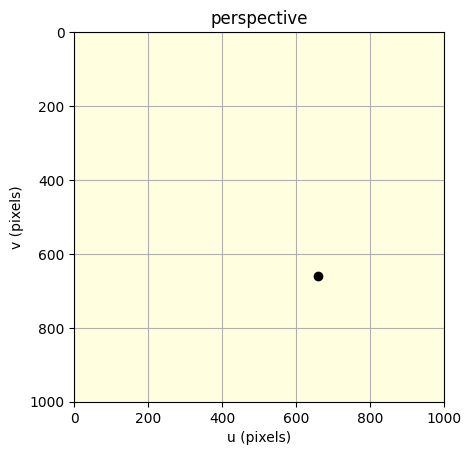

array([[     660],
       [     660]])

In [68]:
camera.plot_point(P)

We can project the same point, but this time with the camera moved 0.5m in the x-direction

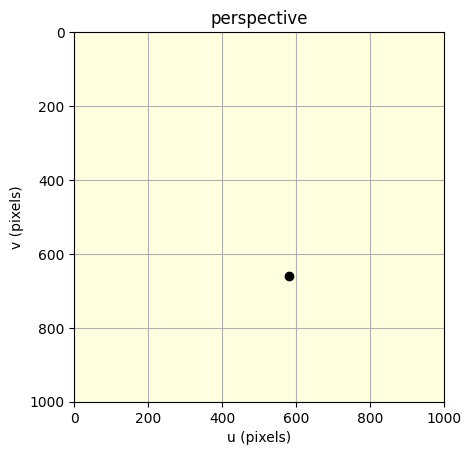

array([[     580],
       [     660]])

In [69]:
from spatialmath import SE3

camera.plot_point(P, pose=SE3(0.5, 0, 0))

and we see that the u-coordinate has decreased.  If we look out along the camera's principal axis then moving the camera to the right causes the image plane point to move to the left.  Note that the vertical coordinate hasn't changed -- as expected.

We can extract the intrinsic matrix

In [70]:
camera.K

array([[     800,        0,      500],
       [       0,      800,      500],
       [       0,        0,        1]])

and the camera matrix

In [71]:
camera.C()

array([[     800,        0,      500,        0],
       [       0,      800,      500,        0],
       [       0,        0,        1,        0]])

and also the camera matrix for the case where the camera is moved

# Image motion & Jacobians

In [72]:
camera = CentralCamera.Default(name='')

P = [1,1,5]

p = camera.project_point(P)
print(p)

J = camera.visjac_p(p, depth=5)
print(J)

J @ [0, 0, 0, 0, 0, 0.1]

[[     660]
 [     660]]
[[    -160        0       32       32     -832      160]
 [       0     -160       32      832      -32     -160]]


array([      16,      -16])

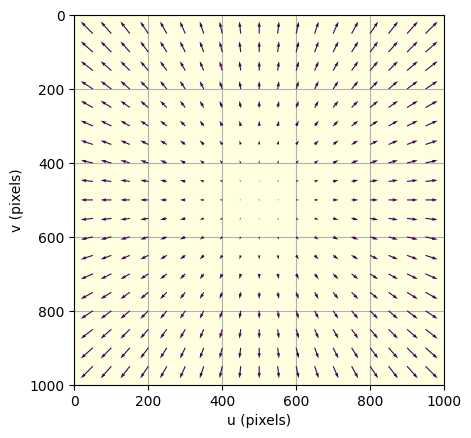

In [73]:
# Tz
camera.flowfield( [0, 0, 1, 0, 0, 0] )


# Homographies

## Homography example 1: camera field of view

We define a central perspective camera (see camera.ipynb for more details on this), that is position up high, looking obliquely downward at the ground

In [74]:
camera = CentralCamera(f=0.012, rho=10e-6, imagesize=1000, 
        pose=SE3(0, 0, 8) * SE3.Rx(-2.8))

And we can plot the camera in the 3D world

(0.0, 10.0)

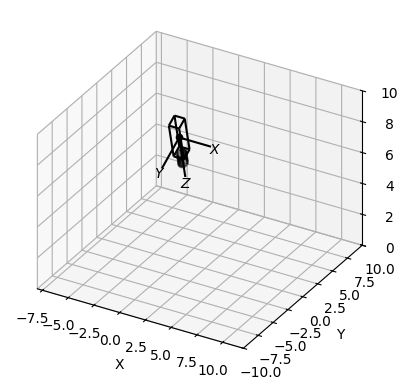

In [75]:
ax = camera.plot(scale=2, shape='camera', color='k', frame=True)
ax.set_xlim(-8, 12)
ax.set_ylim(-10, 10)
ax.set_zlim(0, 10)

A shape on the ground plane is defined by a set of 2D coordinates

In [76]:
P = np.column_stack([[-1, 1], [-1, 2], [ 2,2], [2, 1]])
P

array([[-1, -1,  2,  2],
       [ 1,  2,  2,  1]])

To obtain the coordinates of the points in 3D, we augment each column with a zero, since the ground plane is defined by $z=0$

In [77]:
P0 = np.vstack([P, np.zeros((4,))])
P0

array([[      -1,       -1,        2,        2],
       [       1,        2,        2,        1],
       [       0,        0,        0,        0]])

Now we can project the 3D ground plane points onto the image plane

In [78]:
camera.project_point(P0)

array([[     348,      354,      792,      805],
       [     765,      616,      616,      765]])

The homography is computed from the camera matrix by deleting column two (the z column)

In [79]:
H = np.delete(camera.C(), 2, axis=1)
H

array([[ 1.2e+03,      167, 3.77e+03],
       [       0,     -963, 6.98e+03],
       [       0,    0.335,     7.54]])

We can use this matrix to directly compute the image plane points, by transforming the homogeneous ground plane points

In [80]:
from spatialmath.base import homtrans

homtrans(H, P)

array([[     348,      354,      792,      805],
       [     765,      616,      616,      765]])

which first converts `P` to homogeneous form, performs the multiplication, then converts the resulting homogeneous coordinates to Euclidean.


H is square and of full rank, so it is invertible. This means that we can perform the inverse mapping, from the image plane
to the ground plane.

The camera has a 1000 x 1000 image plane so the coordinates of its corners are


In [81]:
p = np.column_stack([[0, 0], [0, 1000], [1000, 1000], [1000, 0]])
p

array([[   0,    0, 1000, 1000],
       [   0, 1000, 1000,    0]])

and on the ground plane these are the points

In [82]:
from spatialmath.base import homtrans


Pi = homtrans(np.linalg.inv(H), p)
Pi

array([[   -4.15,    -3.08,     3.08,     4.15],
       [    7.25,   -0.426,   -0.426,     7.25]])

Now we can overlay the corners of the camera's field of view onto the "world view" of the imaging setup that we showed earlier

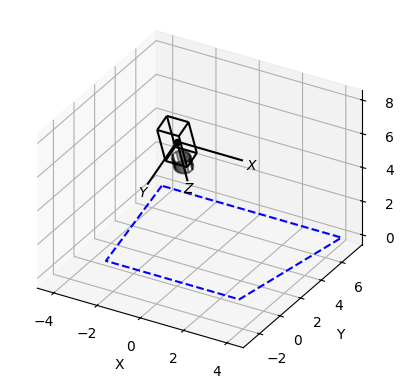

In [83]:
ax = camera.plot(scale=2, shape='camera', color='k', frame=True)
k = [0, 1, 2, 3, 0]
ax.plot(Pi[0, k], Pi[1, k], np.zeros(5), 'b--')


Scroll back up to the previous figure to see the blue dashed line representing the field of view.

## Homography example 2: Perspective rectification

Image: 640 x 426 (uint8), R:G:B [.../images/notre-dame.png]
  R: span=[0, 255]; mean=121.881, 𝜎=71.6726; median=104
  G: span=[0, 255]; mean=125.546, 𝜎=74.6905; median=105
  B: span=[0, 255]; mean=125.139, 𝜎=82.1949; median=99


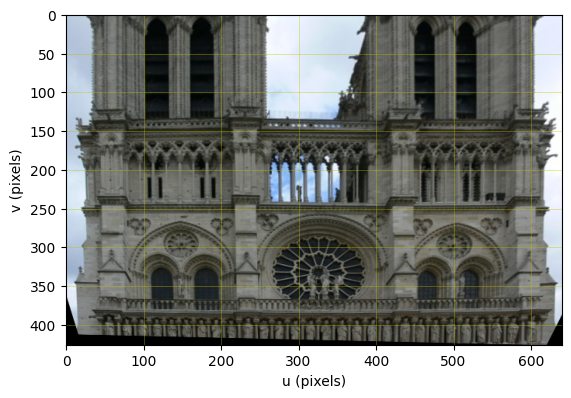

In [84]:
im = Image.Read('notre-dame.png')
print(im)
p1 =   np.array([
    [44.1364,  377.0654], 
    [94.0065,  152.7850],
    [537.8506,  163.4019],
    [611.8247,  366.4486]
]).T

mn = p1.min(axis=1)
mx = p1.max(axis=1)
p2 = np.array([
    [mn[0], mn[0], mx[0], mx[0]],
    [mx[1], mn[1], mn[1], mx[1]]
])

H, _ = CentralCamera.points2H(p1, p2, method='leastsquares')

warped = im.warp_perspective(H)
warped.disp(grid=True)


# Stereo vision

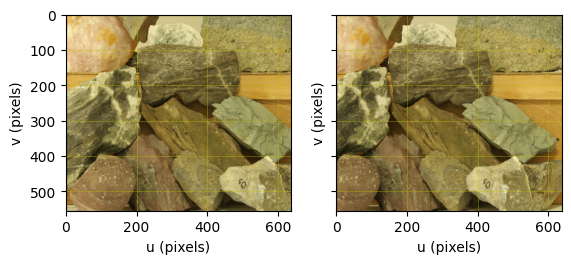

In [85]:
L = Image.Read('rocks2-l.png', reduce=2)
R = Image.Read('rocks2-r.png', reduce=2)

L.stdisp(R)

/Users/pic/opt/miniconda3/envs/dev/lib/python3.12/site-packages/numpy/lib/_arraypad_impl.py:148: RuntimeWarning: invalid value encountered in cast
  padded[left_slice] = value_pair[0]
/Users/pic/opt/miniconda3/envs/dev/lib/python3.12/site-packages/numpy/lib/_arraypad_impl.py:152: RuntimeWarning: invalid value encountered in cast
  padded[right_slice] = value_pair[1]


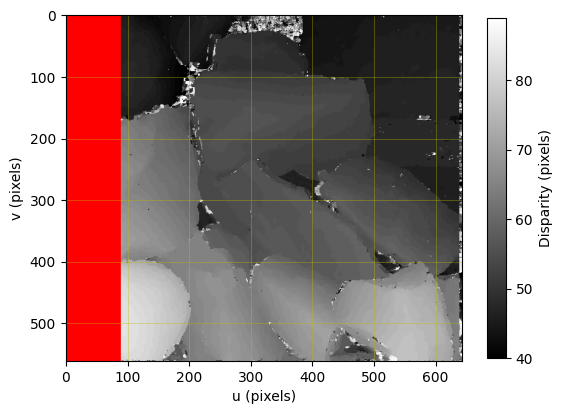

In [86]:
disparity, sim, DSI = L.stereo_simple(R, 3, [40, 90])

disparity.disp(grid=True, badcolor='red', colorbar=dict(shrink=0.92, aspect=20*0.92, label='Disparity (pixels)'))

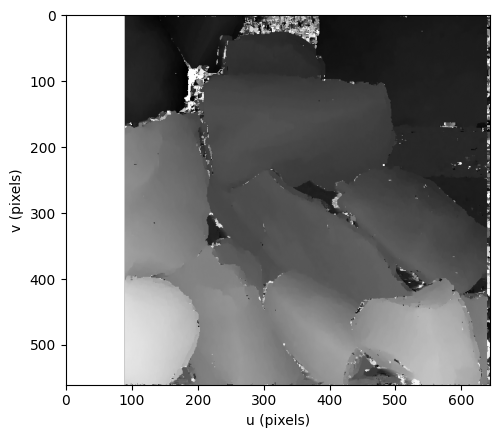

In [87]:
disparity_refined, A = Image.DSI_refine(DSI)
disparity_refined.disp()

# SIFT features

## Finding correspondences between images

First we will load two different views of the same scene

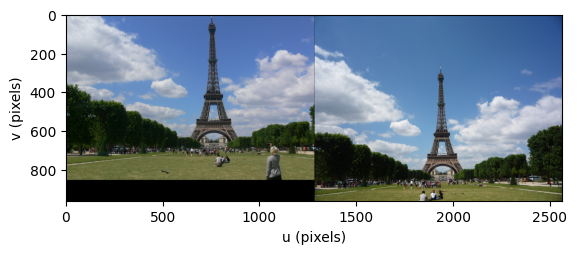

In [88]:
im1 = Image.Read('eiffel-1.png')
im2 = Image.Read('eiffel-2.png')
Image.Hstack((im1,im2)).disp()


and then use SIFT to find corresponding features in the two images

In [89]:
f1 = im1.SIFT()
f2 = im2.SIFT()

In [90]:
len(f1), len(f2)

(2985, 2881)

Then we create a "*match*" object and give it the two sets of features.  It finds the best matches and for each match computes a `distance` which is a measure of dissimilarity.  We sort the matches into decreasing similarity

In [91]:
matches = f1.match(f2)
matches

805 matches

then plot the best 100 matches.  The `plot` method renders the matches onto the original images and overlays lines that connect corresponding points

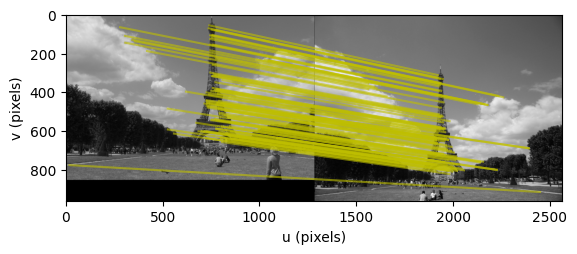

In [92]:
matches[:100].plot('y', alpha=0.6, block=None)

In [93]:
F, resid = matches.estimate(CentralCamera.points2F, method="ransac", confidence=0.99, seed=0)

In [94]:
print(matches)
print(matches[:10].list())

805 matches, with 684 (85.0%) inliers
  0:  +  25.08 (900.3, 636.6) <--> (775.6, 802.3)
  1:  -  26.36 (1118.6, 178.8) <--> (952.5, 418.0)
  2:  +  28.23 (820.6, 519.1) <--> (708.1, 701.6)
  3:  +  29.31 (801.1, 632.4) <--> (694.1, 800.3)
  4:  +  32.40 (746.0, 153.1) <--> (644.5, 392.2)
  5:  +  32.42 (746.4, 183.6) <--> (645.0, 417.4)
  6:  +  35.47 (732.9, 478.7) <--> (633.0, 666.1)
  7:  +  36.72 (621.1, 396.2) <--> (543.3, 598.5)
  8:  +  37.27 (810.2, 336.6) <--> (700.9, 548.8)
  9:  +  38.24 (761.8, 153.4) <--> (657.4, 392.3)
None


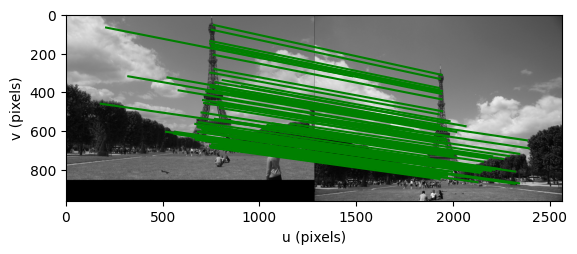

In [95]:
matches.inliers.subset(100).plot(color="g")

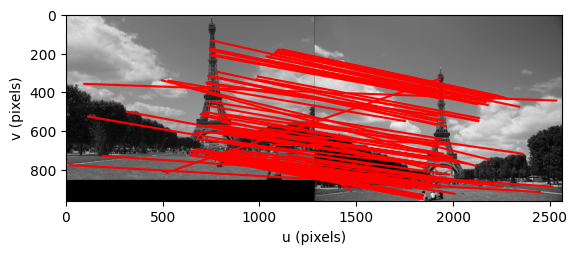

In [96]:
matches.outliers.subset(100).plot(color="r")

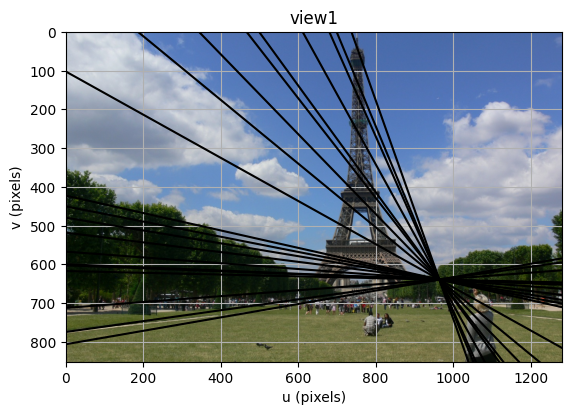

In [97]:
plt.clf()
camera = CentralCamera(name="view1")
camera.disp(im1)

camera.plot_epiline(F.T, matches.inliers.subset(20).p2, color="black")

# Fiducial markers (April tags, ArUco tags)

Image: 1920 x 1280 (uint8), B:G:R [.../images/lab-scene.png]
  B: span=[0, 255]; mean=176.665, 𝜎=60.9151; median=202
  G: span=[0, 255]; mean=168.439, 𝜎=60.7954; median=187
  R: span=[0, 255]; mean=136.055, 𝜎=83.9631; median=146


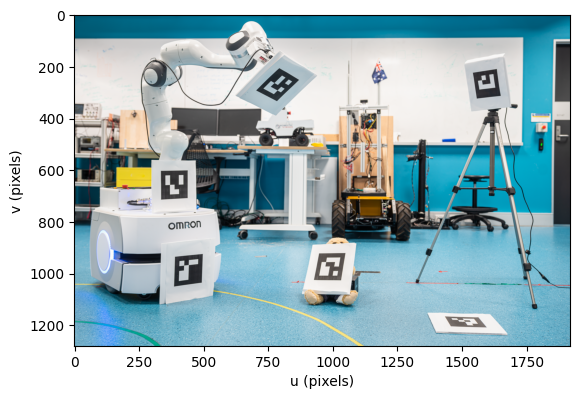

In [98]:
scene = Image.Read("lab-scene.png", rgb=False)
scene.disp();
print(scene)

We are attempting to determine the 3D pose of the arUco markers based on 2D image information, so we need to know some parameters of the imaging geometry.  We create a model of a central projection camera, using as many of the parameters as we know:
-  the focal length, in this case 4.25mm
-  the image size
- the principal point, where the optical axis passes through the image plane
- the pixel size, in this case 1.4μm

From the camera model we can derive the intrinsic parameter matrix

In [99]:
camera = CentralCamera(f=4.25e-3, imagesize=(4032, 3024), pp=(2016, 1512), rho=1.4e-6)
camera.K

array([[3.04e+03,        0, 2.02e+03],
       [       0, 3.04e+03, 1.51e+03],
       [       0,        0,        1]])

There are many different arUco marker families, here we are using `4x4_1000` which is a $4 \times 4$ grid of squares that can encode numbers from 0 to 9999.  We pass in the marker family, the camera intrinsic parameter matrix, and the side length of the marker.  This last parameter is important, because with perspective projection we cannot tell the difference between some large and distance or small and close.  Knowing the size help us estimate distance.

In [100]:
markers = scene.fiducial("4x4_1000", K=camera.K, side=67e-3);

The return is a list of Marker objects, each has the id of the marker, and the coordinates of four corners which is enough to estimate the orientation of the planar marker in 3D , which is shown above.  We pick element 2 of the marker list  

In [101]:
marker = markers[3]
marker.id

np.int32(5)

which is the marker with `id` of 5, the marker being held by the teddy bear.  The corners of this particular fiducial are

In [102]:
marker.corners

array([[     947, 1.05e+03, 1.03e+03,      927],
       [     922,      921, 1.02e+03, 1.02e+03]], dtype=float32)

and we can display them on the original image (zoomed in)

(1200.0, 800.0)

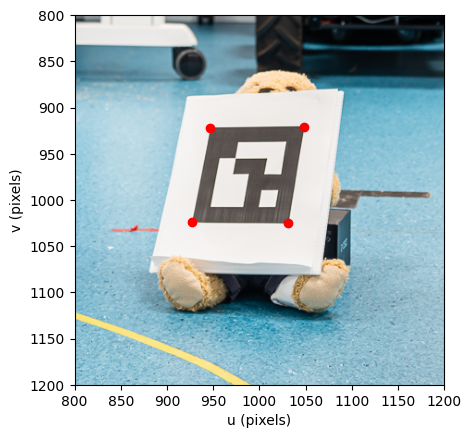

In [103]:
import matplotlib.pyplot as plt

scene.disp(block=None)
plt.plot(marker.corners[0,:], marker.corners[1,:], 'or')
plt.xlim(800, 1200)
plt.ylim(1200, 800)

The pose of the fiducial, with respect to the camera, as an SE(3) matrix is

In [104]:
marker.pose

   0.9811    0.08137  -0.1755   -0.6158    
   0.03359  -0.9651   -0.2597   -0.323     
  -0.1905    0.2489   -0.9496    1.819     
   0         0         0         1         


Finally, we can render a coordinate frame associated with the pose of each fiducial, into the original image.  The fiducial's z-axis is normal to its plane.

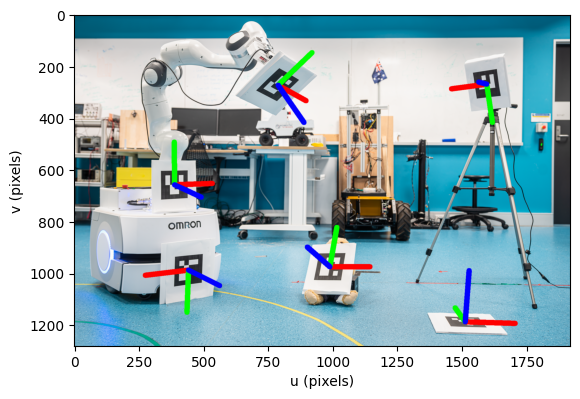

In [105]:
for marker in markers:
    marker.draw(scene, length=0.10, thick=20)
scene.disp();

# Package connectivity

![MVTB ecosystem](support/figs/package-connections.png)

In [106]:
from machinevisiontoolbox import VideoFile

frames = VideoFile("traffic_sequence.mp4")
print("contains", len(frames))


contains 350


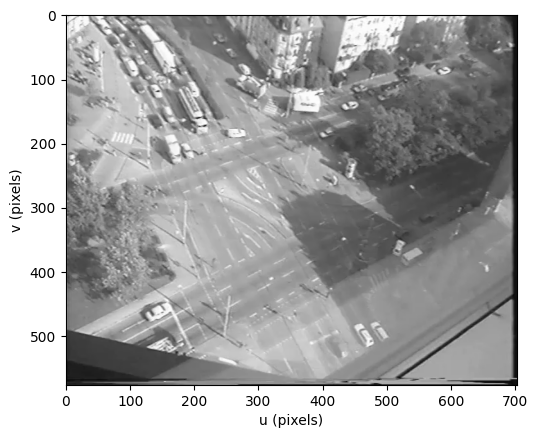

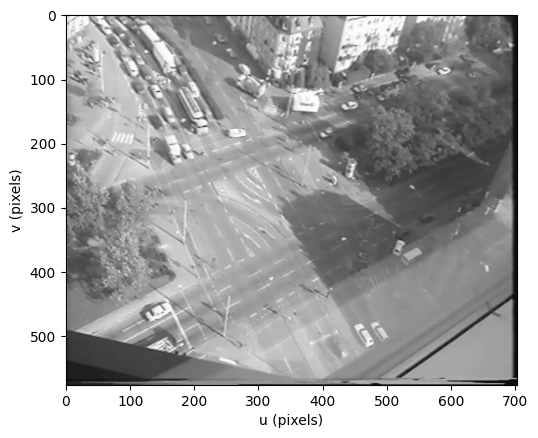

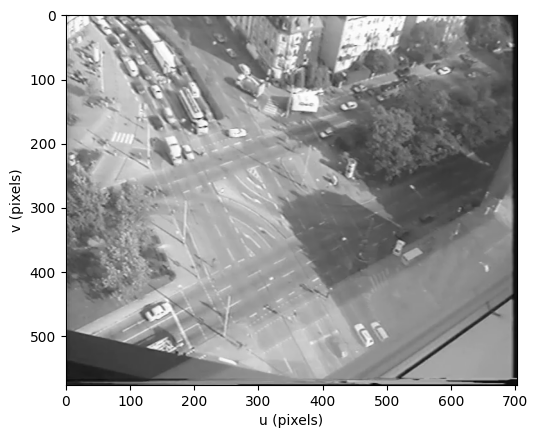

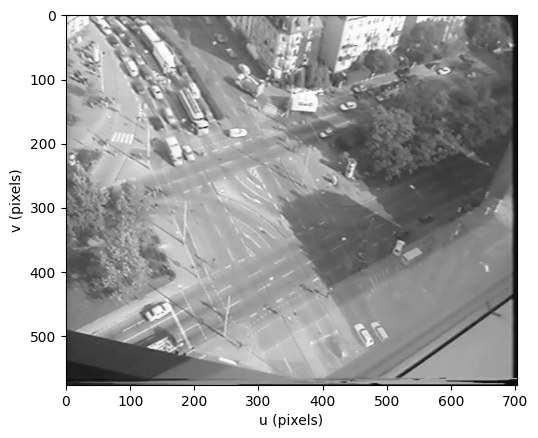

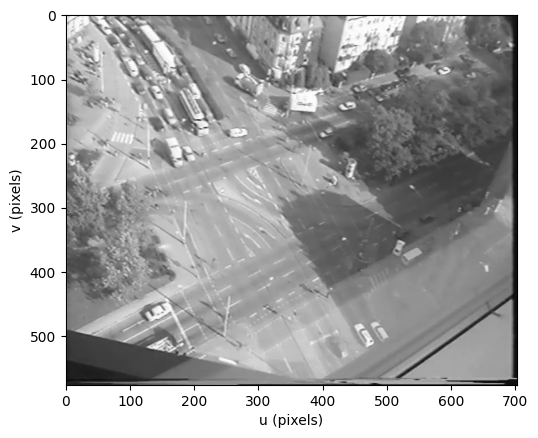

In [107]:
for i, frame in enumerate(frames):
    frame.disp()
    if i >= 4:
        break

In [108]:
# frames.disp(fps=10)

contains 14


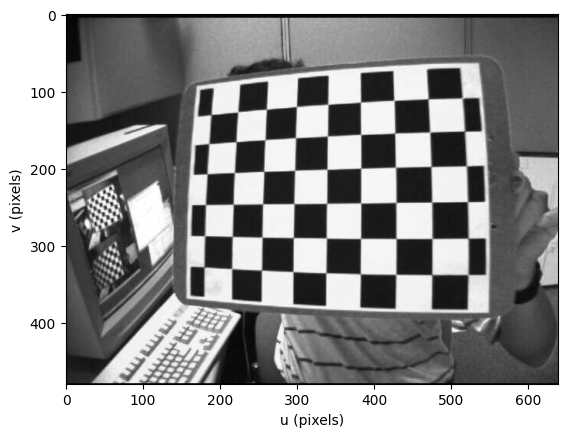

In [109]:
from machinevisiontoolbox import FileCollection

frames = FileCollection("calibration/*.jpg")
print("contains", len(frames))
frames[3].disp();

/var/folders/dh/fyyy32c92ksfpsjp1zrq_8780000gn/T/ipykernel_78911/4117023693.py:3: DeprecationWarning: Deprecated in 2.0.0: use next(webcam) instead of WebCam.grab().
  WebCam("https://uk.jokkmokk.jp/photo/nr4/latest.jpg").grab().disp()


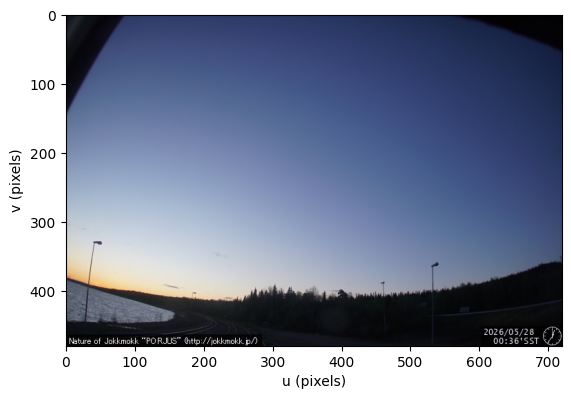

In [110]:
from machinevisiontoolbox import WebCam

WebCam("https://uk.jokkmokk.jp/photo/nr4/latest.jpg").grab().disp()

In [111]:
from machinevisiontoolbox import EarthView

# world = EarthView()
# world.grab(-27.475722, 153.0285, 17).disp()

In [112]:
# frames = FileArchive("calibration.zip", pattern="*.png")

In [113]:
# frames = ROSBag("race_1.bag")